In [1]:
# CELL 1: Install Required Libraries
!pip install shap lime xgboost catboost lightgbm
!pip install pandas numpy matplotlib seaborn scikit-learn statsmodels

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 10.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.6 MB/s eta 0:00:00
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=eb77805f2ce692f668018b6c9630e6003d15f53c1746082bbbaea9d68c9ec468
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [2]:
# CELL 2: Import Libraries
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
import shap
import lime
import lime.lime_tabular

In [3]:
# Cell 3 ko replace karein with this:
from google.colab import files
uploaded = files.upload()  # Is se file upload prompt aayega

df = pd.read_csv("/content/energy_efficiency_data.csv")
# Load the Energy Efficiency Dataset from UCI
#url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00242/ENB2012_data.xlsx"
#df = pd.read_excel(url)


Saving energy_efficiency_data.csv to energy_efficiency_data.csv


In [4]:
# CELL 3: Load and Explore Dataset

# Rename columns for better readability
column_names = {
    'X1': 'Relative_Compactness',
    'X2': 'Surface_Area',
    'X3': 'Wall_Area',
    'X4': 'Roof_Area',
    'X5': 'Overall_Height',
    'X6': 'Orientation',
    'X7': 'Glazing_Area',
    'X8': 'Glazing_Distribution',
    'Y1': 'Heating_Load',
    'Y2': 'Cooling_Load'
}
df.rename(columns=column_names, inplace=True)

print("="*50)
print("DATASET OVERVIEW")
print("="*50)
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print("\nFirst 5 rows:")
print(df.head())

print("\n" + "="*50)
print("DATASET INFO")
print("="*50)
print(df.info())

print("\n" + "="*50)
print("STATISTICAL SUMMARY")
print("="*50)
print(df.describe())

# Check for missing values
print("\n" + "="*50)
print("MISSING VALUES")
print("="*50)
print(df.isnull().sum())

DATASET OVERVIEW
Shape: (768, 10)
Columns: ['Relative_Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area', 'Overall_Height', 'Orientation', 'Glazing_Area', 'Glazing_Area_Distribution', 'Heating_Load', 'Cooling_Load']

First 5 rows:
   Relative_Compactness  Surface_Area  Wall_Area  Roof_Area  Overall_Height  \
0                  0.98         514.5      294.0     110.25             7.0   
1                  0.98         514.5      294.0     110.25             7.0   
2                  0.98         514.5      294.0     110.25             7.0   
3                  0.98         514.5      294.0     110.25             7.0   
4                  0.90         563.5      318.5     122.50             7.0   

   Orientation  Glazing_Area  Glazing_Area_Distribution  Heating_Load  \
0            2           0.0                          0         15.55   
1            3           0.0                          0         15.55   
2            4           0.0                          0         15.55  

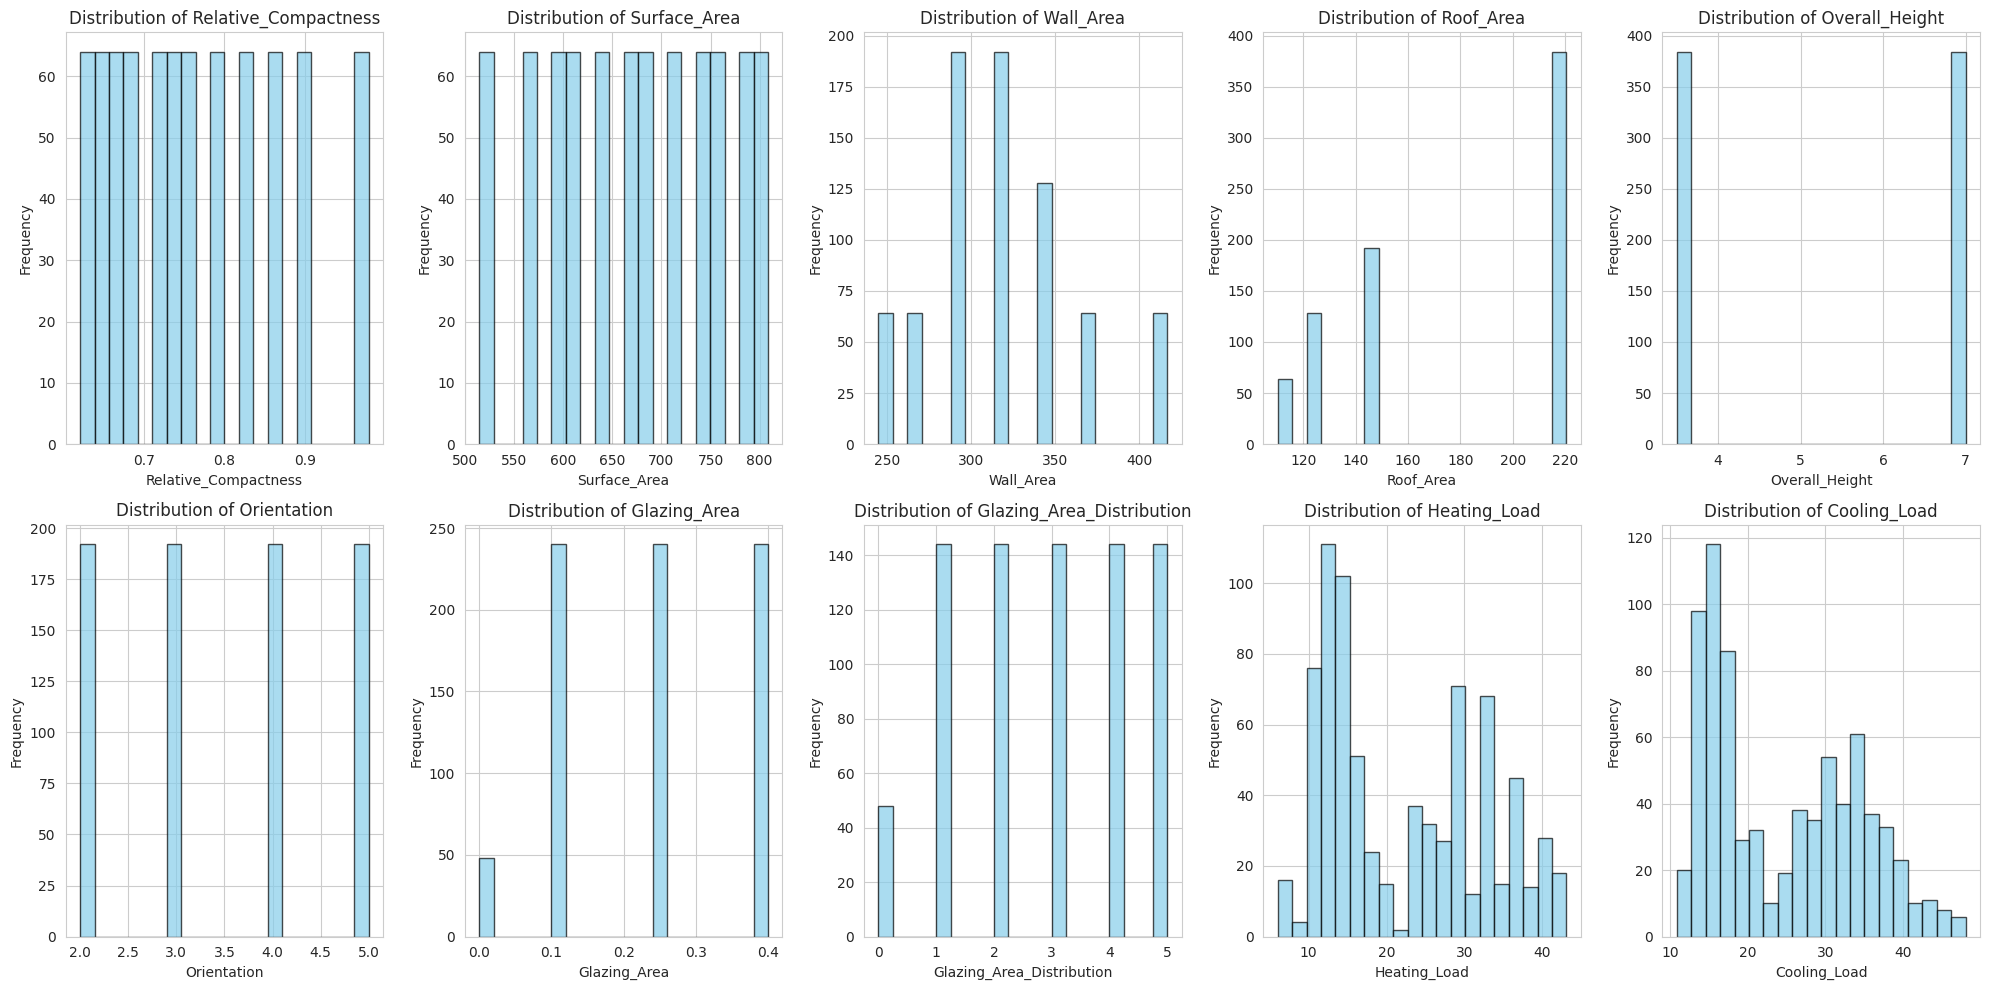

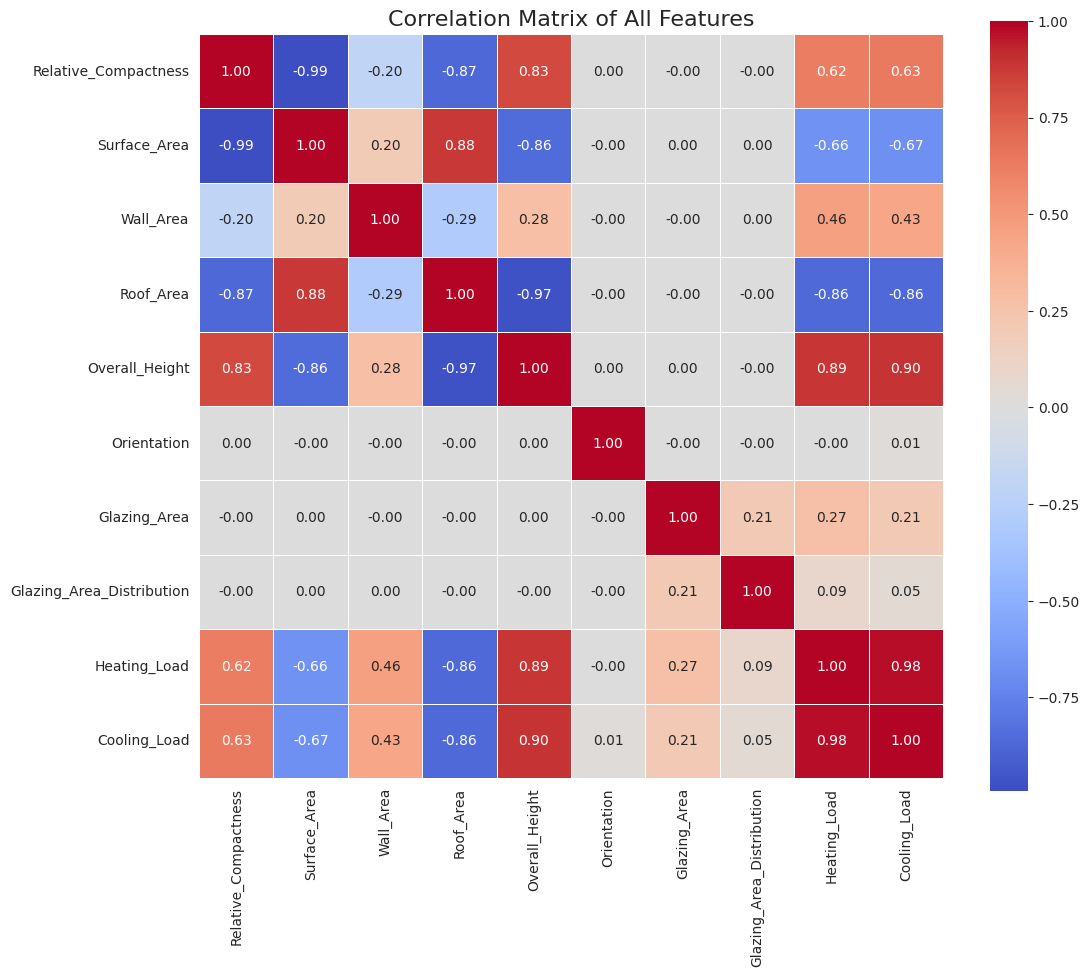

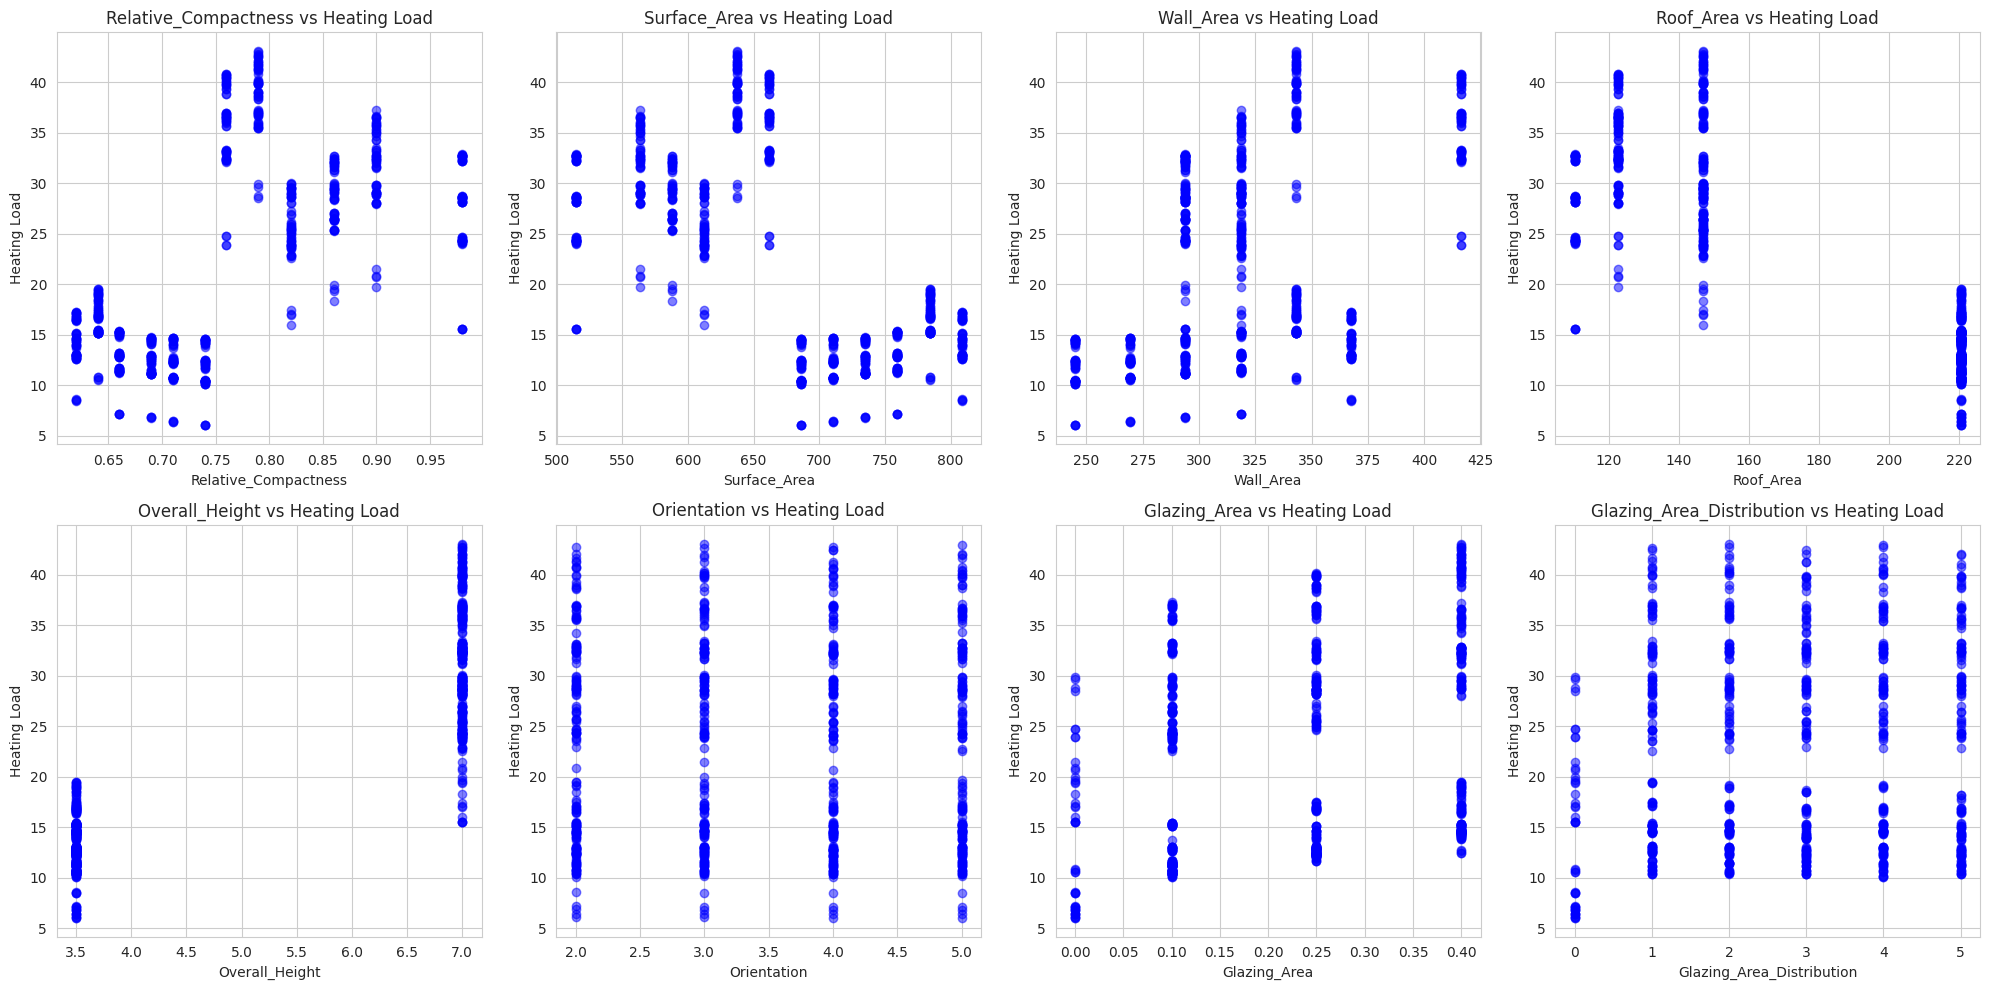

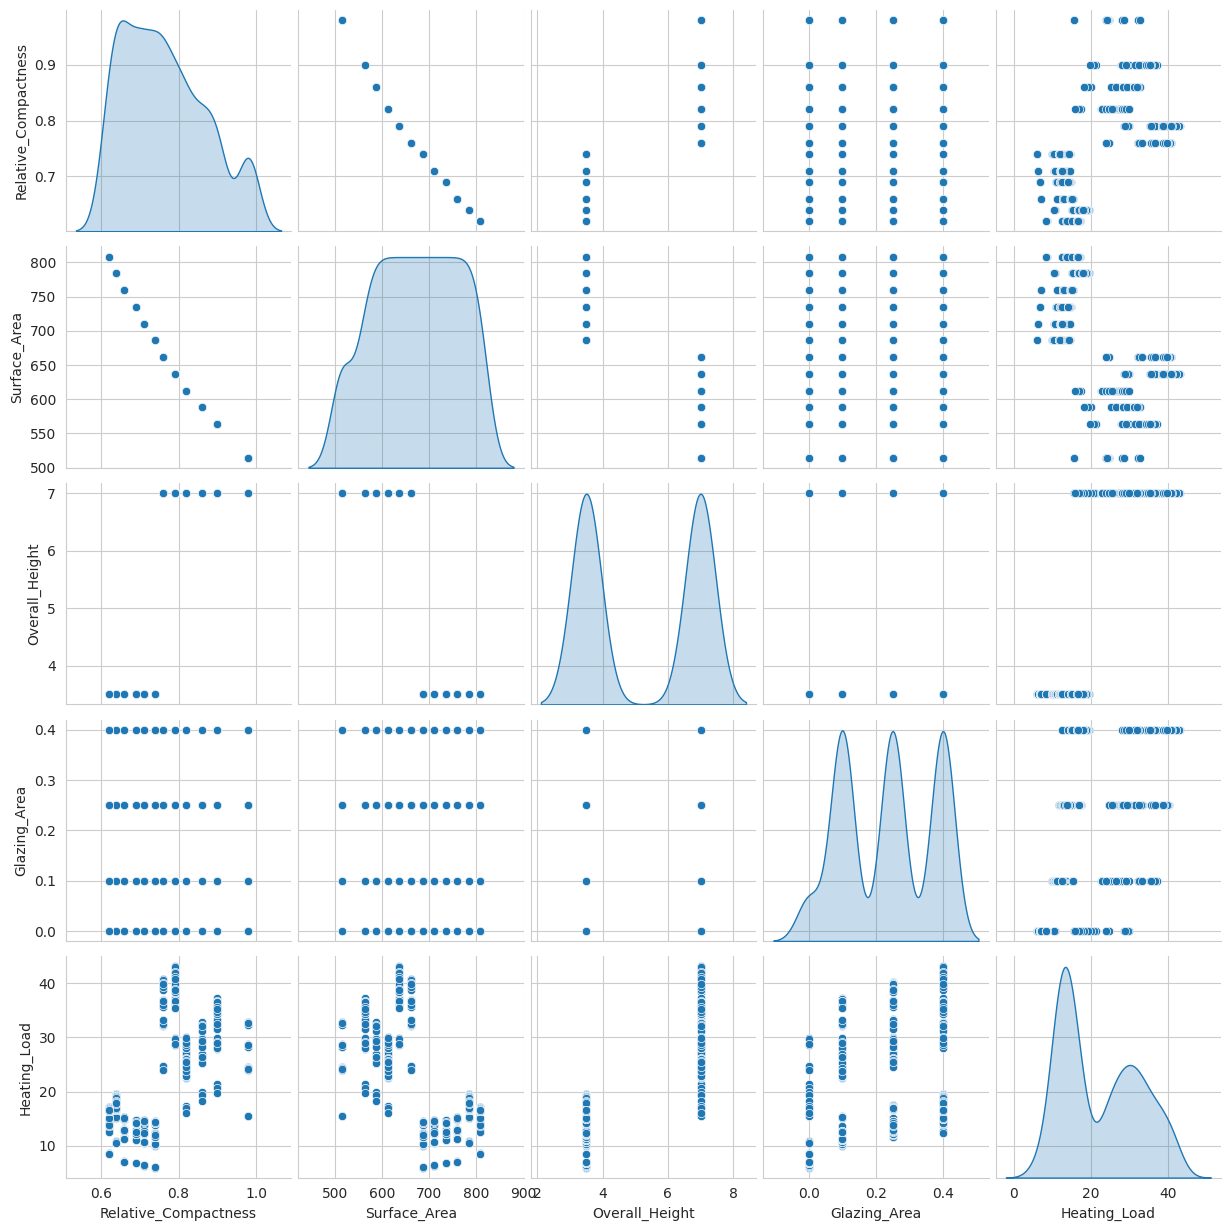

In [7]:
# CELL 4: Exploratory Data Analysis (EDA)
# ============================================
# Set visualization style
sns.set_style("whitegrid")

# 1. Distribution of all features
fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    axes[i].hist(df[col], bins=20, edgecolor='black', alpha=0.7, color='skyblue')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# 2. Correlation Matrix Heatmap
plt.figure(figsize=(12, 10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', linewidths=0.5, square=True)
plt.title('Correlation Matrix of All Features', fontsize=16)
plt.show()

# 3. Feature-Target Relationships
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

features = ['Relative_Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area',
            'Overall_Height', 'Orientation', 'Glazing_Area', 'Glazing_Area_Distribution']

for i, feature in enumerate(features):
    axes[i].scatter(df[feature], df['Heating_Load'], alpha=0.5, color='blue')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Heating Load')
    axes[i].set_title(f'{feature} vs Heating Load')

plt.tight_layout()
plt.show()

# 4. Pairplot of key features
sns.pairplot(df[['Relative_Compactness', 'Surface_Area', 'Overall_Height', 'Glazing_Area', 'Heating_Load']], diag_kind='kde')
plt.show()

OUTLIER DETECTION & ANALYSIS


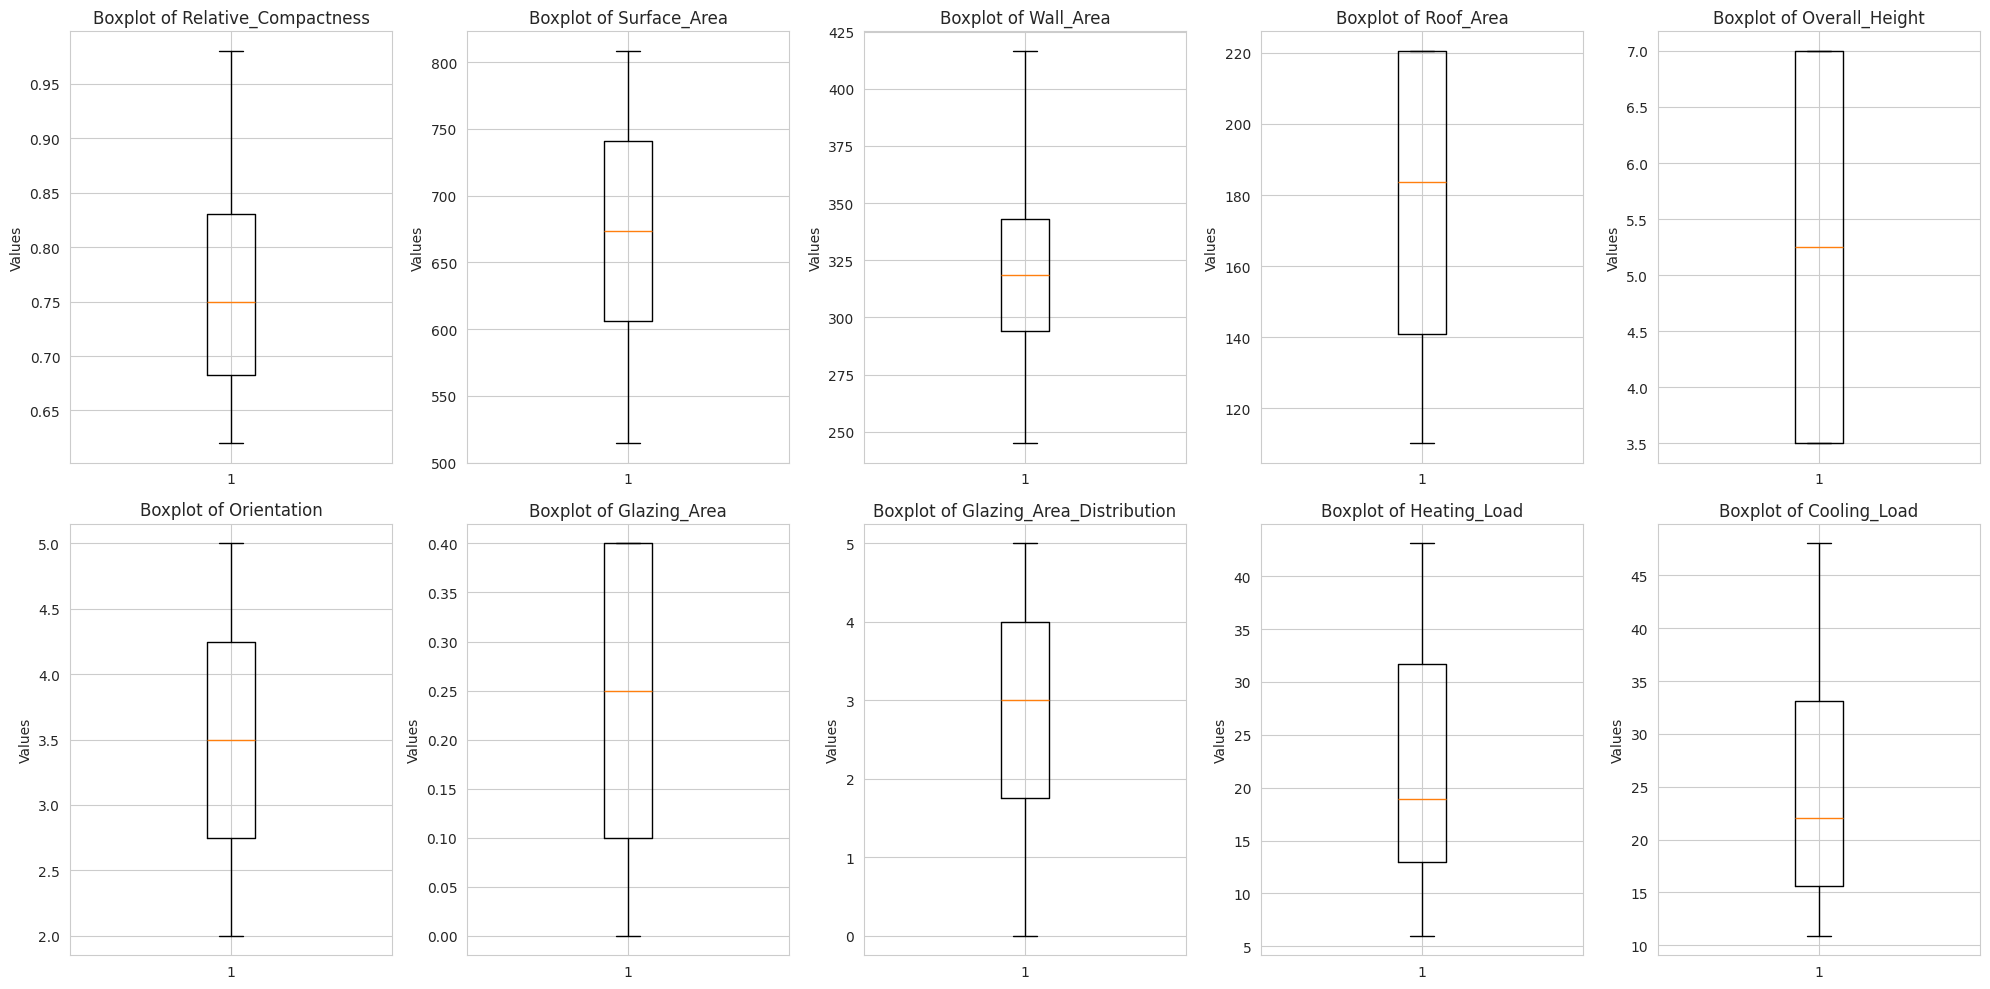

Outlier Analysis Summary:
                           Lower_Bound  Upper_Bound  Outlier_Count  \
Relative_Compactness           0.46125      1.05125            0.0   
Surface_Area                 404.25000    943.25000            0.0   
Wall_Area                    220.50000    416.50000            0.0   
Roof_Area                     21.43750    339.93750            0.0   
Overall_Height                -1.75000     12.25000            0.0   
Orientation                    0.50000      6.50000            0.0   
Glazing_Area                  -0.35000      0.85000            0.0   
Glazing_Area_Distribution     -1.62500      7.37500            0.0   
Heating_Load                 -15.02000     59.68000            0.0   
Cooling_Load                 -10.64875     59.40125            0.0   

                           Outlier_Percentage  
Relative_Compactness                      0.0  
Surface_Area                              0.0  
Wall_Area                                 0.0  
Roof_Area  

In [8]:
 #CELL 5: Outlier Detection & Analysis
# ============================================
print("="*60)
print("OUTLIER DETECTION & ANALYSIS")
print("="*60)

# Boxplots for outliers detection
fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    axes[i].boxplot(df[col])
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_ylabel('Values')

plt.tight_layout()
plt.show()

# IQR Method for outlier detection
outlier_summary = {}

for col in df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_count = len(outliers)
    outlier_percentage = (outlier_count / len(df)) * 100

    outlier_summary[col] = {
        'Lower_Bound': lower_bound,
        'Upper_Bound': upper_bound,
        'Outlier_Count': outlier_count,
        'Outlier_Percentage': outlier_percentage
    }

# Display outlier summary
outlier_df = pd.DataFrame(outlier_summary).T
print("Outlier Analysis Summary:")
print(outlier_df)

# CONCLUSION: Are there outliers?
print("\n" + "="*60)
print("CONCLUSION: OUTLIER ANALYSIS")
print("="*60)

total_outliers = sum(outlier_df['Outlier_Count'])
if total_outliers == 0:
    print("✅ No outliers detected in any feature. No action needed.")
elif total_outliers < 20:
    print(f"⚠️ Very few outliers detected ({total_outliers} total). These can be kept without significant impact.")
    print("   Action: Keep outliers (minimal impact on models)")
else:
    print(f"⚠️ {total_outliers} outliers detected across features.")
    print("   Since this is a relatively small dataset (768 samples), removing outliers may reduce data too much.")
    print("   Action: Keep outliers, but use robust models (Random Forest, XGBoost) that handle outliers well.")

print("\n📌 Note: For tree-based models (Random Forest, XGBoost), outliers have minimal impact,")
print("   so we will keep all data points without removing outliers.")


In [10]:
 #CELL 6: Multicollinearity Check (VIF)
# ============================================
print("="*60)
print("MULTICOLLINEARITY CHECK (VIF - Variance Inflation Factor)")
print("="*60)

# VIF calculation function
def calculate_vif(X):
    vif_data = pd.DataFrame()
    vif_data["Feature"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif_data

# Prepare features for VIF (continuous features only)
X_vif = df[['Relative_Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area',
            'Overall_Height', 'Orientation', 'Glazing_Area', 'Glazing_Area_Distribution']]

# Calculate VIF
vif_results = calculate_vif(X_vif)
print(vif_results.to_string(index=False))

# Interpretation
print("\n" + "="*60)
print("CONCLUSION: VIF ANALYSIS")
print("="*60)

high_vif_features = vif_results[vif_results['VIF'] > 10]
if len(high_vif_features) > 0:
    print("⚠️ Features with VIF > 10 (high multicollinearity):")
    print(high_vif_features.to_string(index=False))
    print("\n   These features are highly correlated:")
    print("   - Surface_Area, Wall_Area, Roof_Area, Overall_Height are building geometry variables")
    print("   - They are naturally correlated (larger buildings have more surface area, etc.)")
    print("\n   📌 Impact on models:")
    print("   - Linear Regression, Ridge, Lasso: Coefficients will be unstable/inflated")
    print("   - Tree-based models (Random Forest, XGBoost): Unaffected by multicollinearity")
    print("\n   ✅ Action: We will use tree-based models as primary models")
    print("   - For Linear/Ridge/Lasso, we will use regularization (Ridge/Lasso already handle this)")
else:
    print("✅ All features have VIF < 10. No significant multicollinearity detected.")

MULTICOLLINEARITY CHECK (VIF - Variance Inflation Factor)
                  Feature        VIF
     Relative_Compactness 168.948751
             Surface_Area        inf
                Wall_Area        inf
                Roof_Area        inf
           Overall_Height 134.035782
              Orientation  10.796725
             Glazing_Area   4.293656
Glazing_Area_Distribution   4.496320

CONCLUSION: VIF ANALYSIS
⚠️ Features with VIF > 10 (high multicollinearity):
             Feature        VIF
Relative_Compactness 168.948751
        Surface_Area        inf
           Wall_Area        inf
           Roof_Area        inf
      Overall_Height 134.035782
         Orientation  10.796725

   These features are highly correlated:
   - Surface_Area, Wall_Area, Roof_Area, Overall_Height are building geometry variables
   - They are naturally correlated (larger buildings have more surface area, etc.)

   📌 Impact on models:
   - Linear Regression, Ridge, Lasso: Coefficients will be unstable/in

In [12]:
 #CELL 7: Categorical Encoding (One-Hot Encoding)
# ============================================
print("="*60)
print("CATEGORICAL ENCODING - One-Hot Encoding")
print("="*60)

# Check unique values in categorical features
print("\nUnique values in Orientation:")
print(df['Orientation'].value_counts().sort_index())

print("\nUnique values in Glazing_Area_Distribution:")
print(df['Glazing_Area_Distribution'].value_counts().sort_index())

# One-Hot Encoding for Orientation and Glazing_Distribution
df_encoded = pd.get_dummies(df, columns=['Orientation', 'Glazing_Area_Distribution'], prefix=['Ori', 'GD'])

print(f"\nOriginal features: {df.shape[1]}")
print(f"Features after One-Hot Encoding: {df_encoded.shape[1]}")

# Display new feature names
print("\nNew feature names:")
print(df_encoded.columns.tolist())

# Show first few rows of encoded data
print("\nFirst 5 rows after One-Hot Encoding:")
print(df_encoded.head())

CATEGORICAL ENCODING - One-Hot Encoding

Unique values in Orientation:
Orientation
2    192
3    192
4    192
5    192
Name: count, dtype: int64

Unique values in Glazing_Area_Distribution:
Glazing_Area_Distribution
0     48
1    144
2    144
3    144
4    144
5    144
Name: count, dtype: int64

Original features: 10
Features after One-Hot Encoding: 18

New feature names:
['Relative_Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area', 'Overall_Height', 'Glazing_Area', 'Heating_Load', 'Cooling_Load', 'Ori_2', 'Ori_3', 'Ori_4', 'Ori_5', 'GD_0', 'GD_1', 'GD_2', 'GD_3', 'GD_4', 'GD_5']

First 5 rows after One-Hot Encoding:
   Relative_Compactness  Surface_Area  Wall_Area  Roof_Area  Overall_Height  \
0                  0.98         514.5      294.0     110.25             7.0   
1                  0.98         514.5      294.0     110.25             7.0   
2                  0.98         514.5      294.0     110.25             7.0   
3                  0.98         514.5      294.0     1

In [13]:
 #CELL 8: Data Preparation (Feature-Target Split)
# ============================================
print("="*60)
print("DATA PREPARATION - Feature-Target Split")
print("="*60)

# Separate features and targets (using encoded data)
X = df_encoded.drop(['Heating_Load', 'Cooling_Load'], axis=1)
y_heating = df_encoded['Heating_Load']
y_cooling = df_encoded['Cooling_Load']

print(f"Features shape: {X.shape}")
print(f"Heating Load shape: {y_heating.shape}")
print(f"Cooling Load shape: {y_cooling.shape}")

# Train-Test Split (80-20) - SAME split for BOTH targets
X_train, X_test, y_train_heat, y_test_heat = train_test_split(
    X, y_heating, test_size=0.2, random_state=42
)

# For cooling, use the SAME indices
# Get indices from the train-test split
train_indices = X_train.index
test_indices = X_test.index

# Use same indices for cooling target
y_train_cool = y_cooling.loc[train_indices]
y_test_cool = y_cooling.loc[test_indices]

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")
print(f"\nConsistency check - Heating train indices: {len(y_train_heat)}")
print(f"Cooling train indices: {len(y_train_cool)}")
print(f"Same split? {all(y_train_heat.index == y_train_cool.index)}")


DATA PREPARATION - Feature-Target Split
Features shape: (768, 16)
Heating Load shape: (768,)
Cooling Load shape: (768,)

Training set size: 614
Testing set size: 154

Consistency check - Heating train indices: 614
Cooling train indices: 614
Same split? True


In [14]:
# CELL 9: Feature Scaling (After One-Hot Encoding)
# ============================================
print("="*60)
print("FEATURE SCALING - StandardScaler")
print("="*60)

# Standard scaling for better performance of some models
# Note: One-Hot encoded features are 0/1, scaling them is fine (they'll be centered)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to dataframe for easier interpretation
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

print("Feature scaling completed!")
print(f"Mean of scaled features: {X_train_scaled_df.mean().mean():.10f}")
print(f"Std of scaled features: {X_train_scaled_df.std().mean():.10f}")

print("\n📌 Note: One-Hot encoded features (Ori_*, GD_*) are also scaled,")
print("   which centers them around 0 and scales to unit variance.")


FEATURE SCALING - StandardScaler
Feature scaling completed!
Mean of scaled features: -0.0000000000
Std of scaled features: 1.0008153283

📌 Note: One-Hot encoded features (Ori_*, GD_*) are also scaled,
   which centers them around 0 and scales to unit variance.


In [15]:
# CELL 10: Machine Learning Models - Training & Evaluation
# ============================================
# Define models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.1),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
}

# Function to evaluate models
def evaluate_models(models, X_train, X_test, y_train, y_test, target_name):
    results = []

    for name, model in models.items():
        # Train the model
        model.fit(X_train, y_train)

        # Make predictions
        y_pred = model.predict(X_test)

        # Calculate metrics
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        results.append({
            'Model': name,
            'Target': target_name,
            'MSE': mse,
            'RMSE': rmse,
            'MAE': mae,
            'R² Score': r2
        })

        print(f"{name} ({target_name}) - RMSE: {rmse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}")

    return pd.DataFrame(results)

print("="*60)
print("TRAINING MODELS FOR HEATING LOAD (With Scaled Data)")
print("="*60)
results_heating = evaluate_models(models, X_train_scaled, X_test_scaled,
                                  y_train_heat, y_test_heat, 'Heating_Load')

print("\n" + "="*60)
print("TRAINING MODELS FOR COOLING LOAD (With Scaled Data)")
print("="*60)
results_cooling = evaluate_models(models, X_train_scaled, X_test_scaled,
                                  y_train_cool, y_test_cool, 'Cooling_Load')


TRAINING MODELS FOR HEATING LOAD (With Scaled Data)
Linear Regression (Heating_Load) - RMSE: 2.8723, MAE: 2.0591, R²: 0.9208
Ridge Regression (Heating_Load) - RMSE: 2.8830, MAE: 2.0739, R²: 0.9203
Lasso Regression (Heating_Load) - RMSE: 2.9751, MAE: 2.1710, R²: 0.9151
Decision Tree (Heating_Load) - RMSE: 0.6418, MAE: 0.4219, R²: 0.9960
Random Forest (Heating_Load) - RMSE: 0.5329, MAE: 0.3703, R²: 0.9973
Gradient Boosting (Heating_Load) - RMSE: 0.5014, MAE: 0.3645, R²: 0.9976
XGBoost (Heating_Load) - RMSE: 0.4023, MAE: 0.2529, R²: 0.9984

TRAINING MODELS FOR COOLING LOAD (With Scaled Data)
Linear Regression (Cooling_Load) - RMSE: 3.1198, MAE: 2.1805, R²: 0.8950
Ridge Regression (Cooling_Load) - RMSE: 3.1276, MAE: 2.1849, R²: 0.8944
Lasso Regression (Cooling_Load) - RMSE: 3.2398, MAE: 2.3030, R²: 0.8867
Decision Tree (Cooling_Load) - RMSE: 2.4088, MAE: 1.3898, R²: 0.9374
Random Forest (Cooling_Load) - RMSE: 2.0272, MAE: 1.2629, R²: 0.9556
Gradient Boosting (Cooling_Load) - RMSE: 1.5393, 

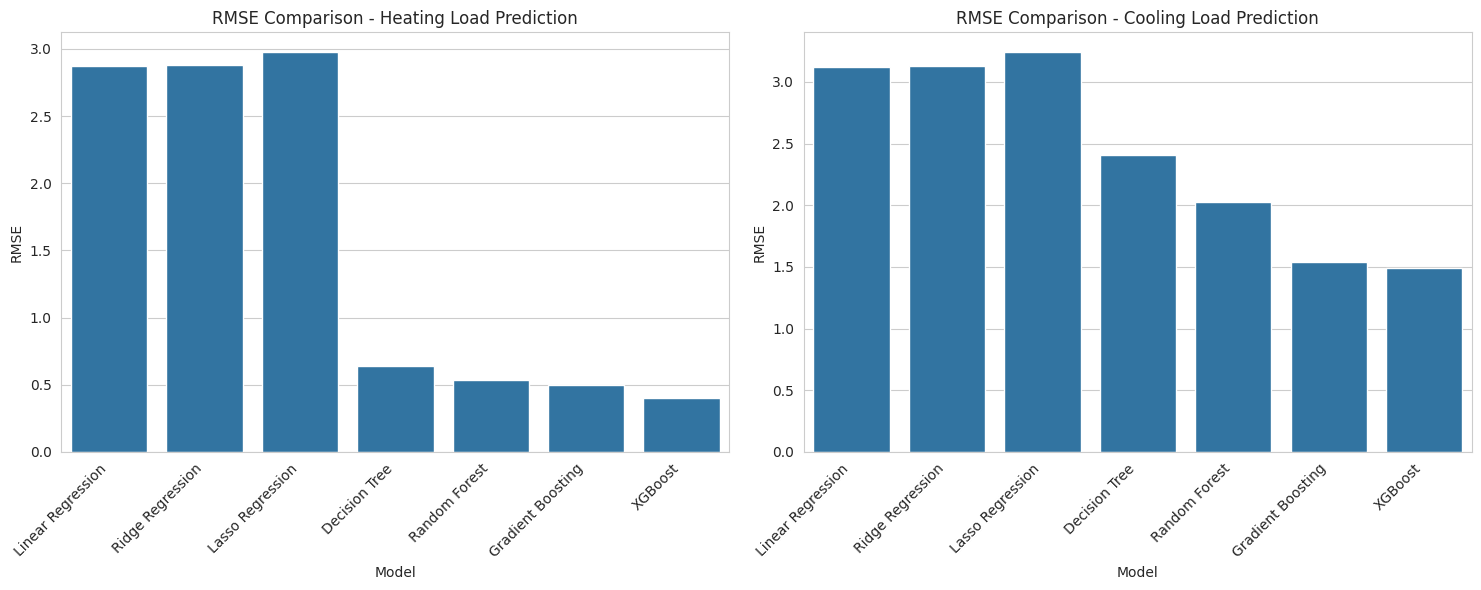

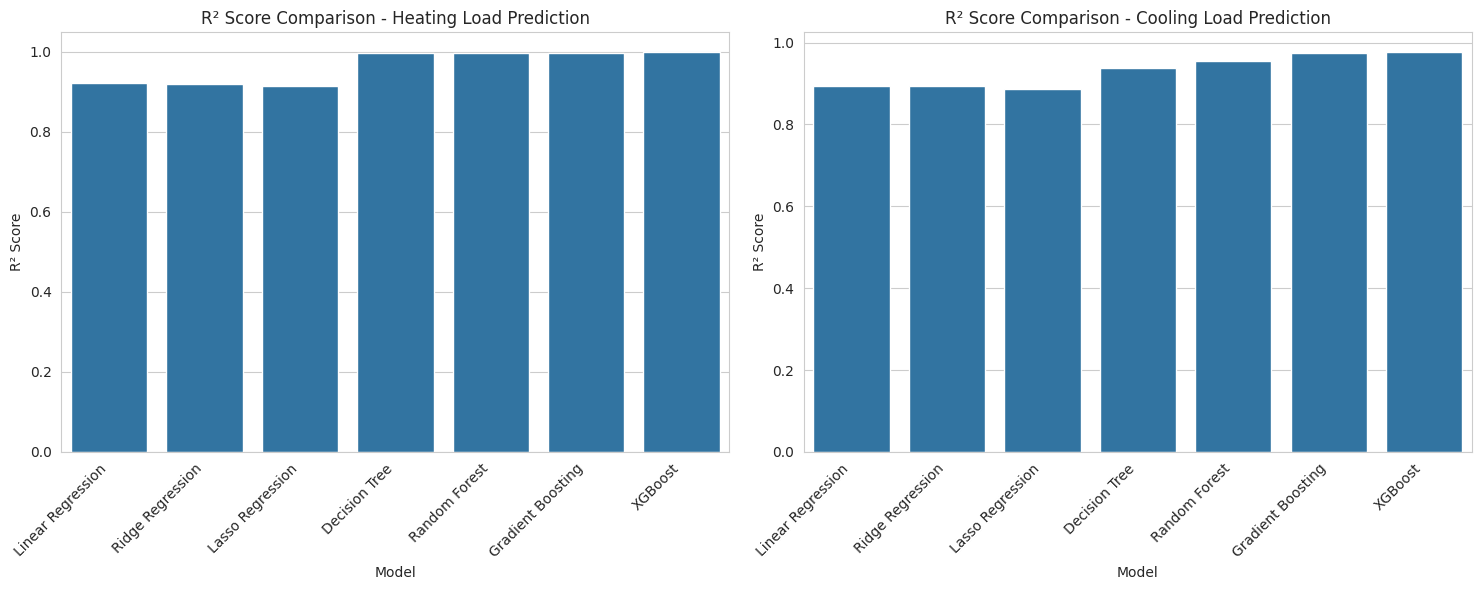

In [16]:
#CELL 11: Compare Model Performance Visually
# ============================================
# Combine results
combined_results = pd.concat([results_heating, results_cooling], ignore_index=True)

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# RMSE Comparison
sns.barplot(data=combined_results[combined_results['Target']=='Heating_Load'],
            x='Model', y='RMSE', ax=axes[0])
axes[0].set_title('RMSE Comparison - Heating Load Prediction')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

sns.barplot(data=combined_results[combined_results['Target']=='Cooling_Load'],
            x='Model', y='RMSE', ax=axes[1])
axes[1].set_title('RMSE Comparison - Cooling Load Prediction')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

# R² Score Comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(data=combined_results[combined_results['Target']=='Heating_Load'],
            x='Model', y='R² Score', ax=axes[0])
axes[0].set_title('R² Score Comparison - Heating Load Prediction')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

sns.barplot(data=combined_results[combined_results['Target']=='Cooling_Load'],
            x='Model', y='R² Score', ax=axes[1])
axes[1].set_title('R² Score Comparison - Cooling Load Prediction')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()


In [17]:
# CELL 12: Hyperparameter Tuning (GridSearchCV)
# ============================================
print("="*60)
print("HYPERPARAMETER TUNING - Random Forest")
print("="*60)

# Parameter grid for Random Forest
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Tune for Heating Load
rf = RandomForestRegressor(random_state=42)
grid_search_heat = GridSearchCV(rf, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search_heat.fit(X_train_scaled, y_train_heat)

print(f"Best parameters for Heating Load: {grid_search_heat.best_params_}")
print(f"Best R² score (CV): {grid_search_heat.best_score_:.4f}")

# Tune for Cooling Load
grid_search_cool = GridSearchCV(rf, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search_cool.fit(X_train_scaled, y_train_cool)

print(f"\nBest parameters for Cooling Load: {grid_search_cool.best_params_}")
print(f"Best R² score (CV): {grid_search_cool.best_score_:.4f}")

# Use best model
best_rf_heat = grid_search_heat.best_estimator_
best_rf_cool = grid_search_cool.best_estimator_

# Evaluate tuned model
y_pred_heat = best_rf_heat.predict(X_test_scaled)
y_pred_cool = best_rf_cool.predict(X_test_scaled)

print(f"\nTuned Random Forest - Heating Load R²: {r2_score(y_test_heat, y_pred_heat):.4f}")
print(f"Tuned Random Forest - Cooling Load R²: {r2_score(y_test_cool, y_pred_cool):.4f}")


HYPERPARAMETER TUNING - Random Forest
Best parameters for Heating Load: {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best R² score (CV): 0.9971

Best parameters for Cooling Load: {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best R² score (CV): 0.9649

Tuned Random Forest - Heating Load R²: 0.9973
Tuned Random Forest - Cooling Load R²: 0.9555


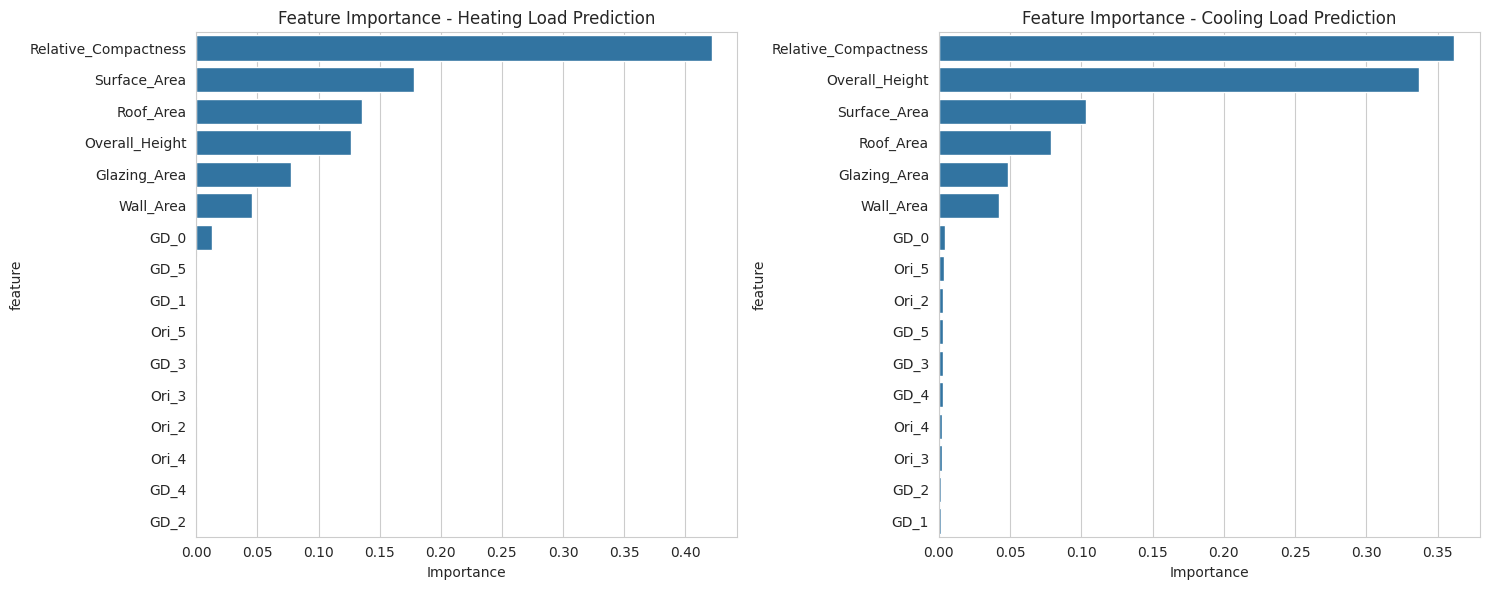

Feature Importance - Heating Load (Top 10):
                 feature  importance
0   Relative_Compactness    0.421722
1           Surface_Area    0.178207
3              Roof_Area    0.135747
4         Overall_Height    0.126377
5           Glazing_Area    0.077612
2              Wall_Area    0.045635
10                  GD_0    0.012913
15                  GD_5    0.000331
11                  GD_1    0.000241
9                  Ori_5    0.000233

Feature Importance - Cooling Load (Top 10):
                 feature  importance
0   Relative_Compactness    0.361603
4         Overall_Height    0.337235
1           Surface_Area    0.103264
3              Roof_Area    0.078947
5           Glazing_Area    0.048347
2              Wall_Area    0.042508
10                  GD_0    0.004228
9                  Ori_5    0.003408
6                  Ori_2    0.003189
15                  GD_5    0.002999


In [18]:
# CELL 13: Feature Importance Analysis
# ============================================
# Get feature importance from Random Forest
feature_importance_heat = pd.DataFrame({
    'feature': X.columns,
    'importance': best_rf_heat.feature_importances_
}).sort_values('importance', ascending=False)

feature_importance_cool = pd.DataFrame({
    'feature': X.columns,
    'importance': best_rf_cool.feature_importances_
}).sort_values('importance', ascending=False)

# Plot feature importance
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(data=feature_importance_heat, x='importance', y='feature', ax=axes[0])
axes[0].set_title('Feature Importance - Heating Load Prediction')
axes[0].set_xlabel('Importance')

sns.barplot(data=feature_importance_cool, x='importance', y='feature', ax=axes[1])
axes[1].set_title('Feature Importance - Cooling Load Prediction')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

print("Feature Importance - Heating Load (Top 10):")
print(feature_importance_heat.head(10))
print("\nFeature Importance - Cooling Load (Top 10):")
print(feature_importance_cool.head(10))


SHAP EXPLANATIONS


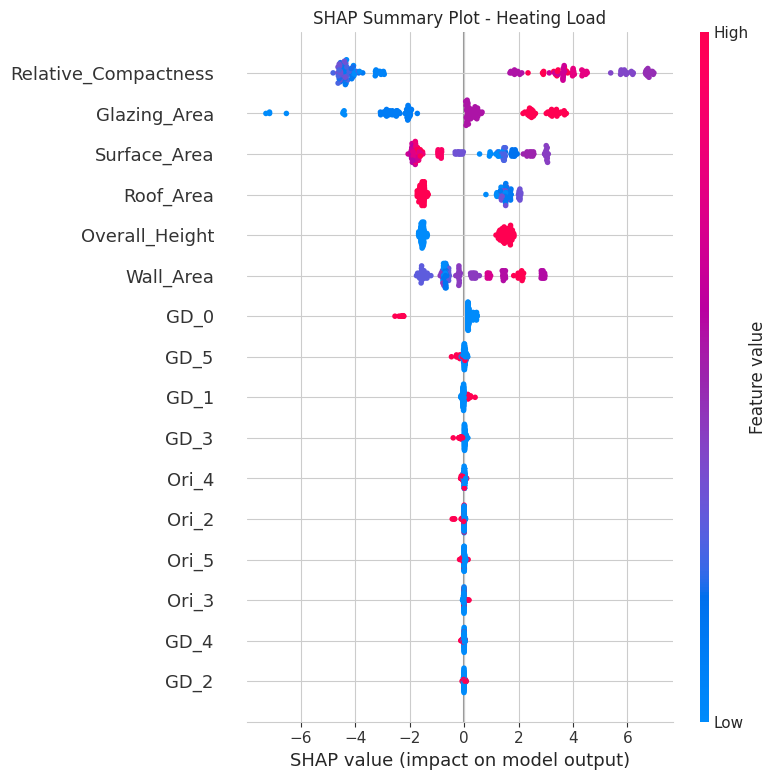

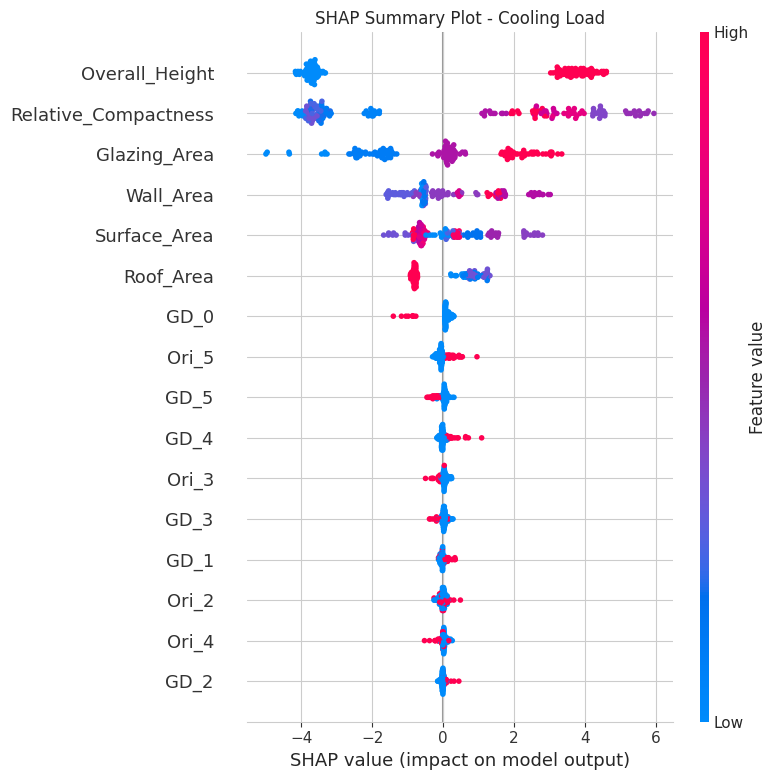

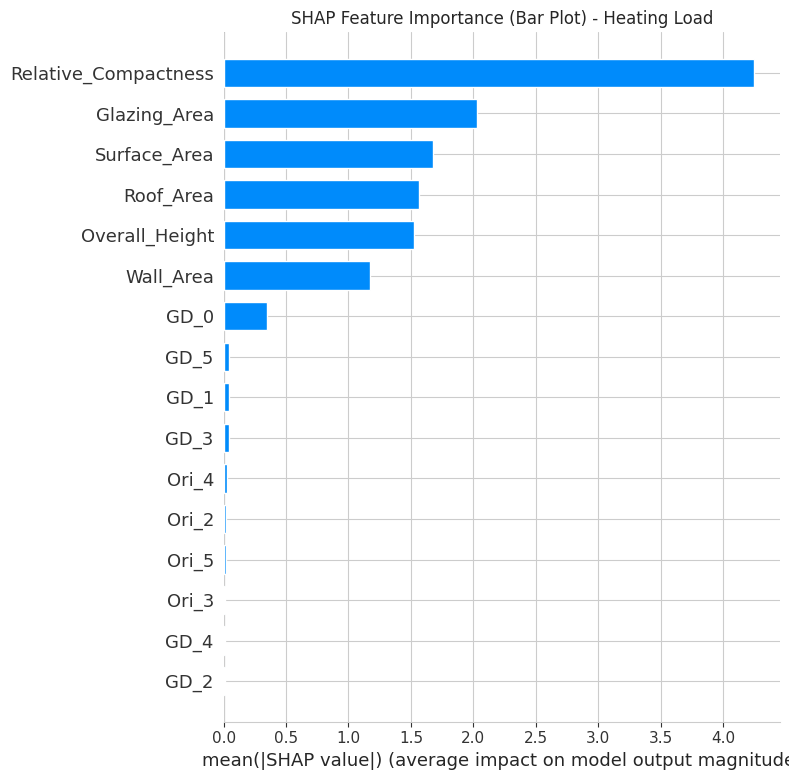

In [19]:
# CELL 14: SHAP Explanations (Model Interpretability)
# ============================================
print("="*60)
print("SHAP EXPLANATIONS")
print("="*60)

# SHAP for Heating Load
explainer_heat = shap.TreeExplainer(best_rf_heat)
shap_values_heat = explainer_heat.shap_values(X_test_scaled)

# SHAP for Cooling Load
explainer_cool = shap.TreeExplainer(best_rf_cool)
shap_values_cool = explainer_cool.shap_values(X_test_scaled)

# SHAP Summary Plot - Heating Load
plt.figure(figsize=(12, 6))
shap.summary_plot(shap_values_heat, X_test_scaled_df, show=False)
plt.title('SHAP Summary Plot - Heating Load')
plt.tight_layout()
plt.show()

# SHAP Summary Plot - Cooling Load
plt.figure(figsize=(12, 6))
shap.summary_plot(shap_values_cool, X_test_scaled_df, show=False)
plt.title('SHAP Summary Plot - Cooling Load')
plt.tight_layout()
plt.show()

# SHAP Bar Plot - Heating Load
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_heat, X_test_scaled_df, plot_type="bar", show=False)
plt.title('SHAP Feature Importance (Bar Plot) - Heating Load')
plt.tight_layout()
plt.show()


In [20]:
# CELL 15: LIME Explanations - Reusable Function
# ============================================
print("="*60)
print("LIME EXPLANATIONS - Reusable Function")
print("="*60)

# Function to get LIME explanation as dictionary (reusable for backend)
def get_lime_explanation(model, X_train, X_test_sample, feature_names, num_features=8):
    """
    Returns LIME explanation as a list of (feature, weight) tuples
    Can be used in backend API
    """
    # Create LIME explainer
    lime_explainer = lime.lime_tabular.LimeTabularExplainer(
        X_train,
        feature_names=feature_names,
        mode='regression',
        verbose=False
    )

    # Get explanation
    exp = lime_explainer.explain_instance(
        X_test_sample,
        model.predict,
        num_features=num_features
    )

    # Return as list of (feature, weight) tuples
    return exp.as_list()

# Test the reusable LIME function
sample_idx = 0  # First test sample
sample = X_test_scaled[sample_idx]
sample_features = X_test_scaled_df.iloc[sample_idx].values

print("LIME Explanation - Heating Load:")
lime_heat = get_lime_explanation(
    best_rf_heat,
    X_train_scaled,
    sample,
    feature_names=X.columns.tolist(),
    num_features=8
)
print("Feature weights (negative = decreases prediction, positive = increases prediction):")
for feature, weight in lime_heat:
    print(f"  {feature}: {weight:.4f}")

print("\nLIME Explanation - Cooling Load:")
lime_cool = get_lime_explanation(
    best_rf_cool,
    X_train_scaled,
    sample,
    feature_names=X.columns.tolist(),
    num_features=8
)
for feature, weight in lime_cool:
    print(f"  {feature}: {weight:.4f}")

# Show in notebook for visualization (optional)
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train_scaled,
    feature_names=X.columns.tolist(),
    mode='regression',
    verbose=False
)

lime_exp_heat = lime_explainer.explain_instance(
    X_test_scaled[sample_idx],
    best_rf_heat.predict,
    num_features=8
)
lime_exp_heat.show_in_notebook(show_table=True)


LIME EXPLANATIONS - Reusable Function
LIME Explanation - Heating Load:
Feature weights (negative = decreases prediction, positive = increases prediction):
  Relative_Compactness <= -0.97: -4.6758
  0.11 < Glazing_Area <= 1.23: 4.3229
  -0.68 < Roof_Area <= 0.96: -3.2701
  Overall_Height <= -0.98: -3.2312
  Wall_Area > 0.56: 1.6075
  Surface_Area > 0.97: -1.4735
  GD_0 <= -0.26: 1.3863
  Ori_4 <= -0.58: 0.2864

LIME Explanation - Cooling Load:
  Overall_Height <= -0.98: -7.8211
  Relative_Compactness <= -0.97: -3.5480
  0.11 < Glazing_Area <= 1.23: 3.0287
  -0.68 < Roof_Area <= 0.96: -1.6449
  Wall_Area > 0.56: 1.3926
  GD_0 <= -0.26: 0.5552
  Ori_5 <= -0.58: -0.4023
  GD_2 <= -0.48: -0.2827


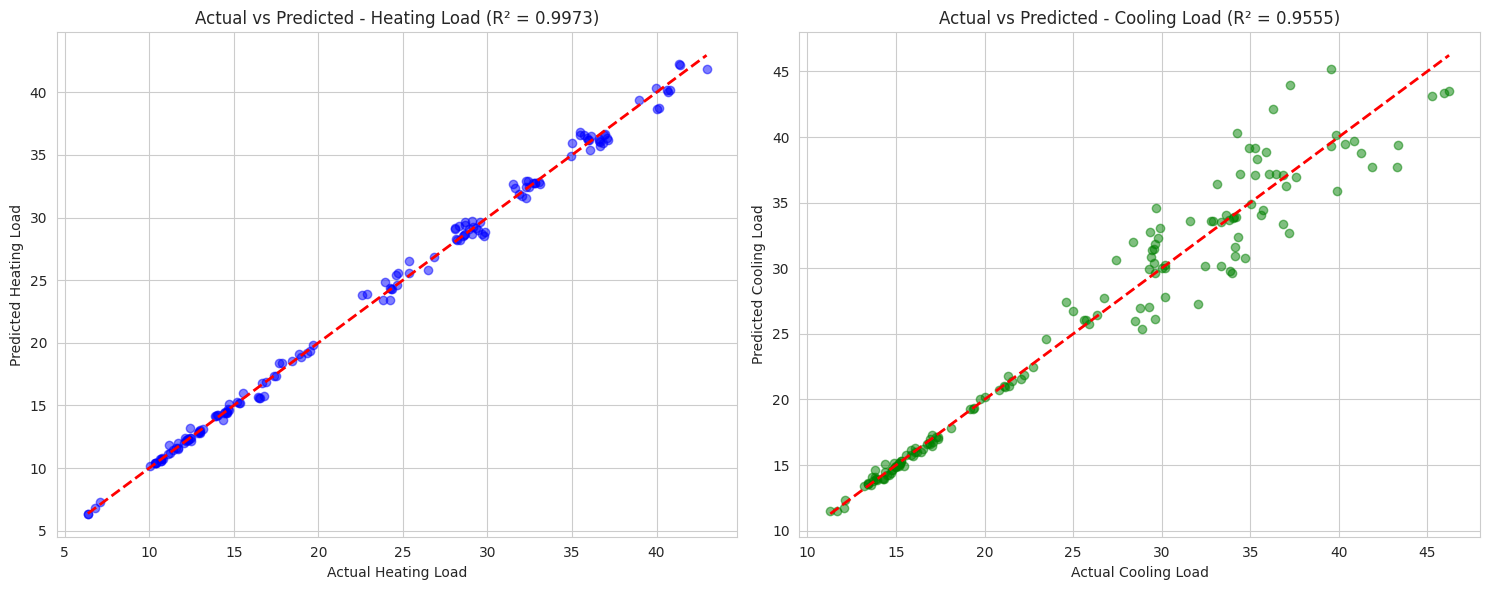

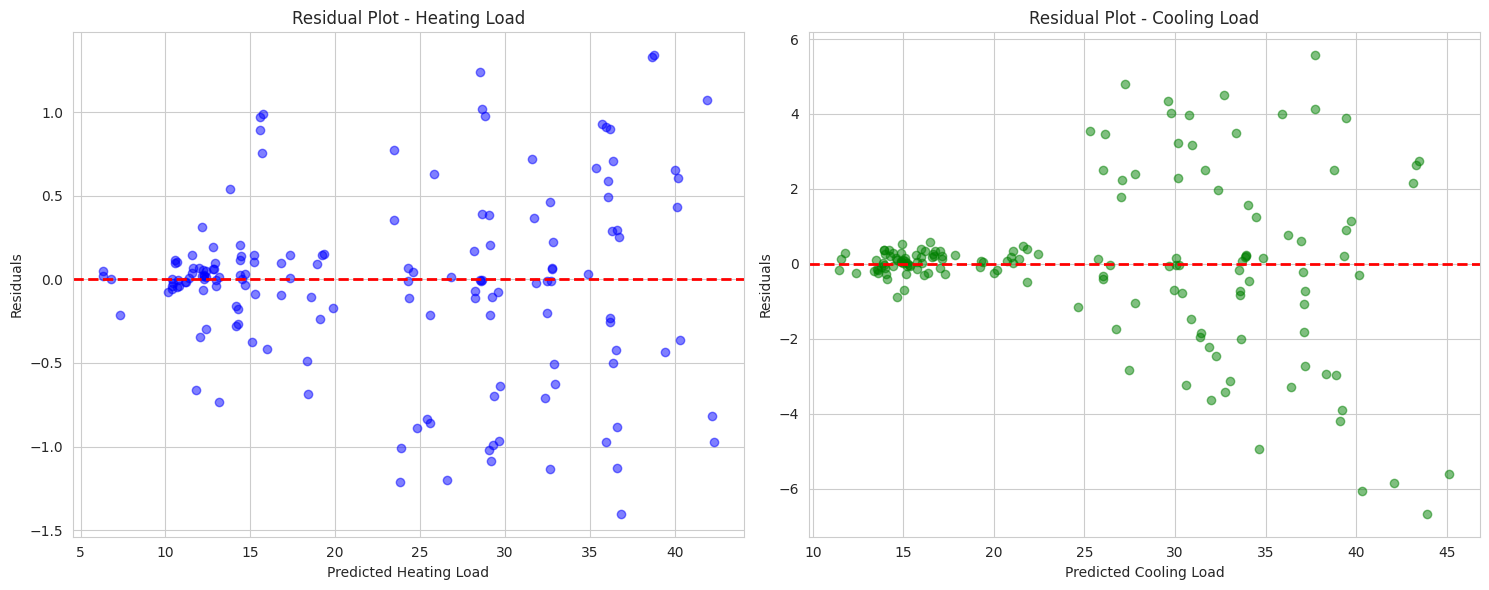

In [21]:
#CELL 16: Model Predictions Visualization
# ============================================
# Actual vs Predicted plots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Heating Load
axes[0].scatter(y_test_heat, y_pred_heat, alpha=0.5, color='blue')
axes[0].plot([y_test_heat.min(), y_test_heat.max()],
             [y_test_heat.min(), y_test_heat.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Heating Load')
axes[0].set_ylabel('Predicted Heating Load')
axes[0].set_title(f'Actual vs Predicted - Heating Load (R² = {r2_score(y_test_heat, y_pred_heat):.4f})')

# Cooling Load
axes[1].scatter(y_test_cool, y_pred_cool, alpha=0.5, color='green')
axes[1].plot([y_test_cool.min(), y_test_cool.max()],
             [y_test_cool.min(), y_test_cool.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Cooling Load')
axes[1].set_ylabel('Predicted Cooling Load')
axes[1].set_title(f'Actual vs Predicted - Cooling Load (R² = {r2_score(y_test_cool, y_pred_cool):.4f})')

plt.tight_layout()
plt.show()

# Residual plots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Heating Load Residuals
residuals_heat = y_test_heat - y_pred_heat
axes[0].scatter(y_pred_heat, residuals_heat, alpha=0.5, color='blue')
axes[0].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0].set_xlabel('Predicted Heating Load')
axes[0].set_ylabel('Residuals')
axes[0].set_title(f'Residual Plot - Heating Load')

# Cooling Load Residuals
residuals_cool = y_test_cool - y_pred_cool
axes[1].scatter(y_pred_cool, residuals_cool, alpha=0.5, color='green')
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Cooling Load')
axes[1].set_ylabel('Residuals')
axes[1].set_title(f'Residual Plot - Cooling Load')

plt.tight_layout()
plt.show()


In [22]:
 #CELL 17: Cross-Validation Scores
# ============================================
print("="*60)
print("CROSS-VALIDATION SCORES (5-fold)")
print("="*60)

# Cross-validation on best models
cv_scores_heat = cross_val_score(best_rf_heat, X_train_scaled, y_train_heat, cv=5, scoring='r2')
cv_scores_cool = cross_val_score(best_rf_cool, X_train_scaled, y_train_cool, cv=5, scoring='r2')

print(f"Heating Load - CV R² Scores: {cv_scores_heat}")
print(f"Heating Load - Mean CV R²: {cv_scores_heat.mean():.4f} ± {cv_scores_heat.std():.4f}")

print(f"\nCooling Load - CV R² Scores: {cv_scores_cool}")
print(f"Cooling Load - Mean CV R²: {cv_scores_cool.mean():.4f} ± {cv_scores_cool.std():.4f}")


CROSS-VALIDATION SCORES (5-fold)
Heating Load - CV R² Scores: [0.997773   0.99693309 0.99697688 0.9974072  0.99618512]
Heating Load - Mean CV R²: 0.9971 ± 0.0005

Cooling Load - CV R² Scores: [0.97014643 0.97073541 0.9700236  0.95360173 0.95975548]
Cooling Load - Mean CV R²: 0.9649 ± 0.0070


In [24]:
# CELL 18: Save Models & Artifacts for Dashboard
# ============================================
import pickle
import joblib

print("="*60)
print("SAVING MODELS FOR DASHBOARD")
print("="*60)

# Create directory for saved models
!mkdir -p saved_models

# Save models
joblib.dump(best_rf_heat, 'saved_models/best_rf_heating.pkl')
joblib.dump(best_rf_cool, 'saved_models/best_rf_cooling.pkl')
joblib.dump(scaler, 'saved_models/scaler.pkl')

# Save feature names and model info
model_info = {
    'features': X.columns.tolist(),
    'targets': ['Heating_Load', 'Cooling_Load'],
    'model_heating_r2': r2_score(y_test_heat, y_pred_heat),
    'model_cooling_r2': r2_score(y_test_cool, y_pred_cool),
    'vif_results': vif_results.to_dict(),
    'outlier_analysis': outlier_df.to_dict(),
    'one_hot_encoding': {
        'Orientation': df['Orientation'].unique().tolist(),
        'Glazing_Area_Distribution': df['Glazing_Area_Distribution'].unique().tolist()
    }
}

with open('saved_models/model_info.pkl', 'wb') as f:
    pickle.dump(model_info, f)

print("✅ Models saved successfully!")
print("\nSaved files:")

SAVING MODELS FOR DASHBOARD
✅ Models saved successfully!

Saved files:


In [25]:
# CELL 19: Test Prediction Function
# ============================================
def predict_energy_efficiency(features_dict):
    """
    features_dict: dict with feature names as keys and values
    Example:
    features_dict = {
        'Relative_Compactness': 0.98,
        'Surface_Area': 514.5,
        'Wall_Area': 294.0,
        'Roof_Area': 110.25,
        'Overall_Height': 7.0,
        'Orientation': 3,
        'Glazing_Area': 0.4,
        'Glazing_Distribution': 1
    }
    """
    # Convert dict to dataframe
    input_df = pd.DataFrame([features_dict])

    # One-Hot encode categorical features
    input_encoded = pd.get_dummies(input_df, columns=['Orientation', 'Glazing_Distribution'], prefix=['Ori', 'GD'])

    # Ensure all columns exist (add missing columns with 0)
    for col in X.columns:
        if col not in input_encoded.columns:
            input_encoded[col] = 0

    # Ensure correct feature order
    input_encoded = input_encoded[X.columns.tolist()]

    # Scale the input
    input_scaled = scaler.transform(input_encoded)

    # Make predictions
    heating_pred = best_rf_heat.predict(input_scaled)[0]
    cooling_pred = best_rf_cool.predict(input_scaled)[0]

    return {
        'Heating_Load': float(heating_pred),
        'Cooling_Load': float(cooling_pred)
    }

# Test the prediction function
test_features = {
    'Relative_Compactness': 0.98,
    'Surface_Area': 514.5,
    'Wall_Area': 294.0,
    'Roof_Area': 110.25,
    'Overall_Height': 7.0,
    'Orientation': 3,
    'Glazing_Area': 0.4,
    'Glazing_Distribution': 1
}

print("="*60)
print("TESTING PREDICTION FUNCTION")
print("="*60)
print(f"Input features: {test_features}")
print("\nPredictions:")
predictions = predict_energy_efficiency(test_features)
print(f"Heating Load: {predictions['Heating_Load']:.2f}")
print(f"Cooling Load: {predictions['Cooling_Load']:.2f}")


TESTING PREDICTION FUNCTION
Input features: {'Relative_Compactness': 0.98, 'Surface_Area': 514.5, 'Wall_Area': 294.0, 'Roof_Area': 110.25, 'Overall_Height': 7.0, 'Orientation': 3, 'Glazing_Area': 0.4, 'Glazing_Distribution': 1}

Predictions:
Heating Load: 32.38
Cooling Load: 33.22


In [26]:
# CELL 20: Model Comparison Summary Table
# ============================================
print("="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)

# Create comprehensive summary table
summary_heat = pd.DataFrame({
    'Model': list(models.keys()),
    'R² (Heating)': [r2_score(y_test_heat, models[m].fit(X_train_scaled, y_train_heat).predict(X_test_scaled)) for m in models.keys()],
    'RMSE (Heating)': [np.sqrt(mean_squared_error(y_test_heat, models[m].fit(X_train_scaled, y_train_heat).predict(X_test_scaled))) for m in models.keys()]
})

summary_cool = pd.DataFrame({
    'Model': list(models.keys()),
    'R² (Cooling)': [r2_score(y_test_cool, models[m].fit(X_train_scaled, y_train_cool).predict(X_test_scaled)) for m in models.keys()],
    'RMSE (Cooling)': [np.sqrt(mean_squared_error(y_test_cool, models[m].fit(X_train_scaled, y_train_cool).predict(X_test_scaled))) for m in models.keys()]
})

# Merge summaries
summary = summary_heat.merge(summary_cool, on='Model')
summary['Average R²'] = (summary['R² (Heating)'] + summary['R² (Cooling)']) / 2

print("\nModel Performance Summary:")
print(summary.to_string(index=False))

# Find best model
best_model_name = summary.loc[summary['Average R²'].idxmax(), 'Model']
print(f"\n🏆 Best Model Overall: {best_model_name}")
print(f"   Average R² Score: {summary['Average R²'].max():.4f}")

print("\n📌 VIF Analysis: Tree-based models (Random Forest, XGBoost) are preferred")
print("   because they handle multicollinearity naturally.")


MODEL COMPARISON SUMMARY

Model Performance Summary:
            Model  R² (Heating)  RMSE (Heating)  R² (Cooling)  RMSE (Cooling)  Average R²
Linear Regression      0.920849        2.872296      0.894958        3.119755    0.907903
 Ridge Regression      0.920260        2.882958      0.894428        3.127623    0.907344
 Lasso Regression      0.915083        2.975060      0.886718        3.239809    0.900901
    Decision Tree      0.996049        0.641765      0.937378        2.408806    0.966713
    Random Forest      0.997276        0.532863      0.955647        2.027224    0.976461
Gradient Boosting      0.997588        0.501379      0.974428        1.539300    0.986008
          XGBoost      0.998447        0.402308      0.976100        1.488126    0.987274

🏆 Best Model Overall: XGBoost
   Average R² Score: 0.9873

📌 VIF Analysis: Tree-based models (Random Forest, XGBoost) are preferred
   because they handle multicollinearity naturally.


In [27]:
# CELL 21: Download Saved Models (Optional)
# ============================================
from google.colab import files

# Create zip file of saved models
!zip -r saved_models.zip saved_models/

# Download the zip file
files.download('saved_models.zip')

print("✅ Models zip file downloaded!")


  adding: saved_models/ (stored 0%)
  adding: saved_models/model_info.pkl (deflated 46%)
  adding: saved_models/best_rf_heating.pkl (deflated 81%)
  adding: saved_models/best_rf_cooling.pkl (deflated 81%)
  adding: saved_models/scaler.pkl (deflated 30%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Models zip file downloaded!


In [28]:
 # CELL 22: Dashboard Backend Code Preview
# ============================================
print("="*60)
print("BACKEND API CODE PREVIEW (FastAPI)")
print("="*60)

api_code = """
# app.py - FastAPI Backend for Energy Efficiency Dashboard

from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
import pandas as pd
import numpy as np
import joblib
import pickle
import shap
from typing import List, Tuple

app = FastAPI(title="Energy Efficiency XAI Dashboard")

# Load models
model_heat = joblib.load('saved_models/best_rf_heating.pkl')
model_cool = joblib.load('saved_models/best_rf_cooling.pkl')
scaler = joblib.load('saved_models/scaler.pkl')

with open('saved_models/model_info.pkl', 'rb') as f:
    model_info = pickle.load(f)

# Feature names
features = model_info['features']

class EnergyFeatures(BaseModel):
    Relative_Compactness: float
    Surface_Area: float
    Wall_Area: float
    Roof_Area: float
    Overall_Height: float
    Orientation: int
    Glazing_Area: float
    Glazing_Distribution: int

@app.get("/")
def home():
    return {"message": "Energy Efficiency XAI Dashboard API", "model_info": model_info}

@app.post("/predict")
def predict(features: EnergyFeatures):
    # Convert to dataframe
    input_df = pd.DataFrame([features.dict()])

    # One-Hot encode
    input_encoded = pd.get_dummies(input_df, columns=['Orientation', 'Glazing_Distribution'], prefix=['Ori', 'GD'])

    # Add missing columns
    for col in features:
        if col not in input_encoded.columns:
            input_encoded[col] = 0

    input_encoded = input_encoded[features]
    input_scaled = scaler.transform(input_encoded)

    # Predict
    heating_pred = float(model_heat.predict(input_scaled)[0])
    cooling_pred = float(model_cool.predict(input_scaled)[0])

    # Get feature importance for this prediction
    explainer_heat = shap.TreeExplainer(model_heat)
    shap_values_heat = explainer_heat.shap_values(input_scaled)

    return {
        "predictions": {
            "Heating_Load": heating_pred,
            "Cooling_Load": cooling_pred
        },
        "features": features.dict(),
        "shap_values": shap_values_heat[0].tolist()
    }

@app.post("/lime_explain")
def lime_explain(features: EnergyFeatures):
    # This would need X_train_scaled to work
    # You would load X_train_scaled from saved file
    return {"message": "LIME explanation endpoint"}

# Run: uvicorn app:app --reload
"""
print(api_code)

print("\n" + "="*60)
print("✅ ALL CELLS COMPLETED SUCCESSFULLY!")
print("="*60)
print("\n📊 Summary of Improvements:")
print("   ✅ One-Hot Encoding for Orientation & Glazing_Distribution")
print("   ✅ LIME as reusable function (returns .as_list())")
print("   ✅ Outlier analysis with conclusions and actions")
print("   ✅ VIF analysis for multicollinearity")
print("   ✅ Consistent train-test split for both targets")
print("\n📁 Models saved in 'saved_models/' folder")
print("🔽 Download ZIP file from Colab to use in dashboard")


BACKEND API CODE PREVIEW (FastAPI)

# app.py - FastAPI Backend for Energy Efficiency Dashboard

from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
import pandas as pd
import numpy as np
import joblib
import pickle
import shap
from typing import List, Tuple

app = FastAPI(title="Energy Efficiency XAI Dashboard")

# Load models
model_heat = joblib.load('saved_models/best_rf_heating.pkl')
model_cool = joblib.load('saved_models/best_rf_cooling.pkl')
scaler = joblib.load('saved_models/scaler.pkl')

with open('saved_models/model_info.pkl', 'rb') as f:
   model_info = pickle.load(f)

# Feature names
features = model_info['features']

class EnergyFeatures(BaseModel):
   Relative_Compactness: float
   Surface_Area: float
   Wall_Area: float
   Roof_Area: float
   Overall_Height: float
   Orientation: int
   Glazing_Area: float
   Glazing_Distribution: int

@app.get("/")
def home():
   return {"message": "Energy Efficiency XAI Dashboard API", "model_info": model_info}

@ap